In [1]:
import qiskit

print(qiskit.__version__)

2.5.1


In [2]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, Reset
import matplotlib.pyplot as plt
import math
import numpy as np

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


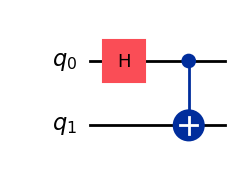

In [3]:
qc = QuantumCircuit(2)
qc.h(0)  #hadamard applied to qubit 0
qc.cx(0, 1)  #cnot gate applied between q0 and q1

print(qc.draw())
qc.draw("mpl")

In [4]:
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.quantum_info import Statevector

In [5]:
qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc) #oracle advantage
print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [28]:
a=0.0001*math.pi #value
n=7 #number of qubits
m=2**n #number of time steps should be 2^n-1, this is the hilbert space dimension 128x128 Umatrix
circ=QuantumCircuit(n,1)  #7 qubits 1 classical bit:class stores info

In [29]:
for i in range(n-1):
 circ.h(i+1)  #hadamard gate applied --> superposition on qubits 1-6 not 0
#q0=0, other 6 qubits are an equal superposition of all 64 values (2^6)

In [30]:
#building custom unitary matrix
U=np.zeros((m,m), dtype=np.complex128)
for i in range(0, m, 2):  #0,2,4,..126
 U[i][i]=np.cos(i*a)
 U[i][i+1]=np.sin(i*a)
 U[i+1][i]=-np.sin(i*a)
 U[i+1][i+1]=np.cos(i*a)

print(U)

[[ 1.        +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [-0.        +0.j  1.        +0.j  0.        +0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.9999998 +0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 ...
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.99924132+0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
   0.99921665+0.j  0.03957373+0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
  -0.03957373+0.j  0.99921665+0.j]]


In [31]:
gate=UnitaryGate(U)
circ.append(gate,[0,1,2,3,4,5,6])

state=Statevector(circ)
print(state)

Statevector([ 1.25000000e-01+0.j,  0.00000000e+00+0.j,  1.24999975e-01+0.j,
             -7.85398112e-05+0.j,  1.24999901e-01+0.j, -1.57079591e-04+0.j,
              1.24999778e-01+0.j, -2.35619309e-04+0.j,  1.24999605e-01+0.j,
             -3.14158935e-04+0.j,  1.24999383e-01+0.j, -3.92698436e-04+0.j,
              1.24999112e-01+0.j, -4.71237782e-04+0.j,  1.24998791e-01+0.j,
             -5.49776942e-04+0.j,  1.24998421e-01+0.j, -6.28315885e-04+0.j,
              1.24998001e-01+0.j, -7.06854580e-04+0.j,  1.24997533e-01+0.j,
             -7.85392996e-04+0.j,  1.24997014e-01+0.j, -8.63931102e-04+0.j,
              1.24996447e-01+0.j, -9.42468866e-04+0.j,  1.24995830e-01+0.j,
             -1.02100626e-03+0.j,  1.24995164e-01+0.j, -1.09954325e-03+0.j,
              1.24994448e-01+0.j, -1.17807980e-03+0.j,  1.24993684e-01+0.j,
             -1.25661589e-03+0.j,  1.24992869e-01+0.j, -1.33515149e-03+0.j,
              1.24992006e-01+0.j, -1.41368656e-03+0.j,  1.24991093e-01+0.j,
            

In [32]:
y=np.zeros(64)
for i in range(64):
    y[i]=state[2*i] #counts from measurement

/tmp/ipykernel_568/3857000769.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  y[i]=state[2*i] #counts from measurement


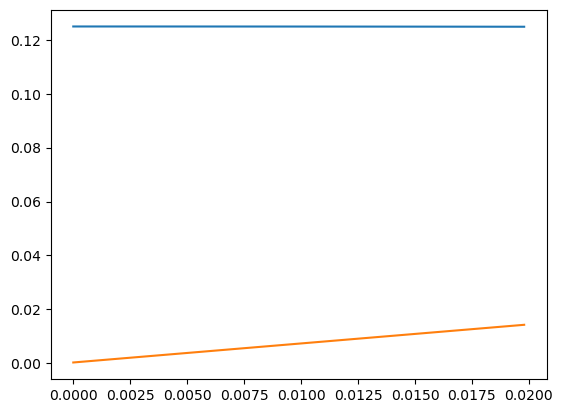

In [33]:
s=np.zeros(64)
for i in range(64):
 s[i]=0.0001*math.pi*i
plt.plot(s,y) #basis index?
plt.plot(s,0.707*np.sin(s+0.0001*math.pi))

In [34]:
circ.reset(0)
circ_measured = circ.measure_all(inplace=False)


from qiskit.primitives import StatevectorSampler
sampler=StatevectorSampler()
job=sampler.run([circ_measured],shots=1000)
result= job.result()
circ_measured = circ.measure_all(inplace=False)


from qiskit.primitives import StatevectorSampler
sampler=StatevectorSampler()
job=sampler.run([circ_measured],shots=1000)
result= job.result()
shot_data_array = result.data.c.array
print(f"Raw shot-level data array: {shot_data_array}")

#You can still get a Counts dictionary from this data if needed
counts_from_array = result.data.c0.get_counts()
print(f"Counts from array data: {counts_from_array}")
counts_ideal=result[0].data["meas"].get_counts()
plot_histogram(counts_ideal)


AttributeError: 'PrimitiveResult' object has no attribute 'data'

In [25]:
circ_measured = circ.measure_all(inplace=False)


from qiskit.primitives import StatevectorSampler
sampler=StatevectorSampler()
job=sampler.run([circ_measured],shots=1000)
result= job.result()
shot_data_array = result.data.c.array
print(f"Raw shot-level data array: {shot_data_array}")

# You can still get a Counts dictionary from this data if needed
counts_from_array = result.data.c0.get_counts()
print(f"Counts from array data: {counts_from_array}")
counts_ideal=result[0].data["meas"].get_counts()
plot_histogram(counts_ideal)



AttributeError: 'PrimitiveResult' object has no attribute 'data'

In [26]:
shot_data_array = result.data.c.array
print(f"Raw shot-level data array: {shot_data_array}")

# You can still get a Counts dictionary from this data if needed
counts_from_array = result.data.c0.get_counts()
print(f"Counts from array data: {counts_from_array}")
 


AttributeError: 'PrimitiveResult' object has no attribute 'data'

In [27]:
outcomes_array = np.array(list(counts_ideal.keys()))

print(f"Outcomes array: {outcomes_array}")


NameError: name 'counts_ideal' is not defined

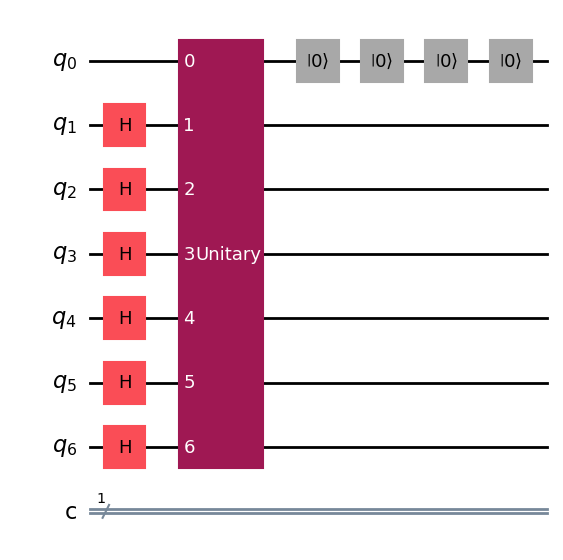

In [23]:
circ.draw('mpl')





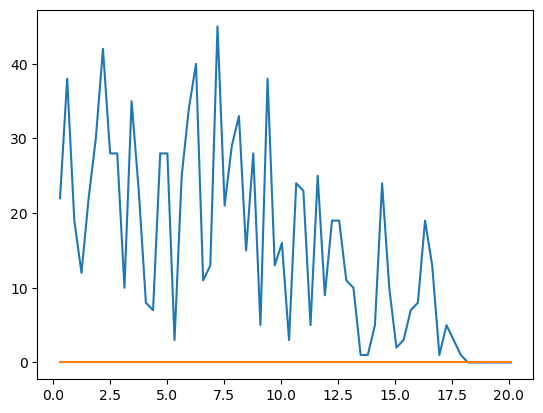

In [22]:
t = np.arange(0.314, 20.106, 0.314)
a=[22, 38, 19, 12, 22, 30, 42, 28, 28, 10, 35, 23,  8,  7, 28, 28,  3, 25, 34, 40, 11, 13, 45, 21,
 29, 33, 15, 28,  5, 38, 13, 16,  3, 24, 23, 5, 25,  9, 19, 19, 11, 10,  1,  1,  5,24, 10,  2,
  3,  7,  8, 19, 13,  1,  5,  3,  1,0,0,0,0,0,0,0]
plt.plot(t,a)
plt.plot(t,y)
plt.show()